In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

model_order = [
    "ContextFold", "ContraFold", "EternaFold", "IPKnot", "NeuralFold",
    "NUPACK", "RNAFold", "RNAStructure", "pKnots", "Simfold",
    "MXFold", "MXFold2", "SPOT-RNA"
]

In [2]:
model_order_indexes = {
    "ContextFold": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "ContraFold": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "EternaFold": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "IPKnot": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "NeuralFold": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "NUPACK": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "RNAFold": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "RNAStructure": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "pKnots": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "Simfold": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "MXFold": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "MXFold2": [("sens", 5), ("ppv", 6), ("f1", 7)],
    "SPOT-RNA": [("sens", 5), ("ppv", 6), ("f1", 7)]
}

In [3]:
metrics_order = ["Sensitivity", "PPV", "F1"]

with open("data/pdb_canonical_matched_0.txt") as fh:
    data = fh.readlines()

data[:2]

['ContextFold, 4ZNP_chain_0, GGGAUACAGGACUGGCGGAUUAGUGGGAAACCACGUGGACUGUAUCCGAAAAAAAGCCGACCGCCUGGGCAUC, .((((((((.............((((....)))).....)))))))).........................., ((..(.((((..((((((.(..((((....))))..(((.....))).......).))).))))))).)..)), 0.3333333333333333, 0.19047619047619047, 0.24242424242424246\n',
 'ContextFold, 2ZY6_chain_0, GCCCGGAUAGUGUCCUUGGGAAACCGAGUCCGGGCACC, (((((((..(.(...........))...)))))))..., ((((((((.......((((....))))))))))))..., 0.7777777777777778, 0.5833333333333334, 0.6666666666666666\n']

In [4]:
data[0].split(", ")

['ContextFold',
 '4ZNP_chain_0',
 'GGGAUACAGGACUGGCGGAUUAGUGGGAAACCACGUGGACUGUAUCCGAAAAAAAGCCGACCGCCUGGGCAUC',
 '.((((((((.............((((....)))).....))))))))..........................',
 '((..(.((((..((((((.(..((((....))))..(((.....))).......).))).))))))).)..))',
 '0.3333333333333333',
 '0.19047619047619047',
 '0.24242424242424246\n']

In [5]:
metrics = ["sens", "ppv", "f1"]

model_stat_map = {}
for m in model_order:
    model_stat_map[m] = {}
    for metric in metrics:
        model_stat_map[m][metric] = []

data = [d.split(", ") for d in data]

# metric_coords = [("sens", 5), ("ppv", 6), ("f1", 7)]
for d in data:
    model = d[0]
    metric_coords = model_order_indexes[model]
    for metric, idx in metric_coords:
        val = float(d[idx].strip())
        model_stat_map[model][metric].append(val)



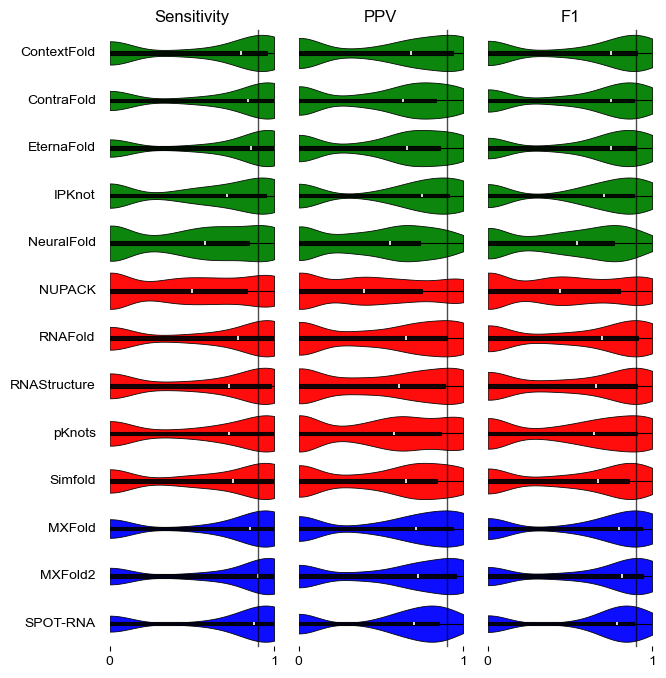

In [11]:
import data_utils as du

m_pretty_key_map = {"Sensitivity": "sens", "PPV": "ppv", "F1": "f1"}

n_rows = len(model_order)
n_cols = len(metrics_order)

fig_w = max(1.8 * n_cols, 7)
fig_h = max(0.4 * n_rows, 8)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_w, fig_h),
    squeeze=False,
    sharex=False,
    sharey=False
)

for row_idx, model in enumerate(model_order):
    model_color = du.get_model_color(model)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    for col_idx, metric in enumerate(metrics_order):
        ax = axes[row_idx, col_idx]

        metric_key = m_pretty_key_map[metric]
        values = model_stat_map[model][metric_key]
        # values = [v for v in values if v is not None and not np.isnan(v)]

        violin = ax.violinplot(
            values,
            positions=[0],
            widths=0.8,
            showmeans=False,
            showmedians=False,
            showextrema=False,
            vert=False
        )

        for body in violin["bodies"]:
            body.set_facecolor(model_color)
            body.set_edgecolor("black")
            body.set_alpha(0.95)
            body.set_linewidth(0.6)

        # Add inner boxplot inside the violin
        box = ax.boxplot(
            values,
            positions=[0],
            widths=0.08,
            vert=False,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(
                facecolor="black",
                edgecolor="black",
                linewidth=0.8,
                alpha=0.9
            ),
            medianprops=dict(
                color="white",
                linewidth=1.2
            ),
            whiskerprops=dict(
                color="black",
                linewidth=0.8
            ),
            capprops=dict(
                color="black",
                linewidth=0.8
            )
        )

        if "cmedians" in violin:
            violin["cmedians"].set_color("black")
            violin["cmedians"].set_linewidth(1.0)


        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-0.5, 0.5)

        if row_idx == n_rows - 1:
            ax.set_xticks([0.0, 1.0])
        else:
            ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(axis="y", alpha=0.2, linewidth=0.5)

        for spine in ax.spines.values():
            spine.set_visible(False)

        if col_idx == 0:
            ax.set_ylabel(model, rotation=0, ha="right", va="center", labelpad=10)

        if row_idx == 0:
            ax.set_title(metric)

# plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.15)

fig.canvas.draw()
threshold = 0.9

for col_idx in range(n_cols):
    top_ax = axes[0, col_idx]
    bottom_ax = axes[-1, col_idx]

    # Convert x=0.9 from data coordinates to figure coordinates
    x_display = top_ax.transData.transform((threshold, 0))[0]
    x_fig = fig.transFigure.inverted().transform((x_display, 0))[0]

    # Get vertical span of the whole column in figure coordinates
    y_bottom = bottom_ax.get_position().y0
    y_top = top_ax.get_position().y1

    line = Line2D(
        [x_fig, x_fig],
        [y_bottom, y_top],
        transform=fig.transFigure,
        color="black",
        linewidth=1,
        alpha=0.7,
        zorder=10
    )

    fig.add_artist(line)

plt.savefig("pdb_violin_plot.png", dpi=500)
plt.show()


In [55]:
# Testing that the numbers are different
print("Unique values")
for model in model_order:
    for metric in metrics_order:
        metric_key = m_pretty_key_map[metric]
        values = model_stat_map[model][metric_key]

        uniq_values = set(values)
        print(f"{model} - {metric}: {len(uniq_values)}")
    print()

Unique values
ContextFold - Sensitivity: 79
ContextFold - PPV: 76
ContextFold - F1: 95

ContraFold - Sensitivity: 64
ContraFold - PPV: 88
ContraFold - F1: 104

EternaFold - Sensitivity: 60
EternaFold - PPV: 85
EternaFold - F1: 100

IPKnot - Sensitivity: 74
IPKnot - PPV: 67
IPKnot - F1: 99

NeuralFold - Sensitivity: 76
NeuralFold - PPV: 88
NeuralFold - F1: 115

NUPACK - Sensitivity: 73
NUPACK - PPV: 82
NUPACK - F1: 96

RNAFold - Sensitivity: 68
RNAFold - PPV: 82
RNAFold - F1: 98

RNAStructure - Sensitivity: 78
RNAStructure - PPV: 79
RNAStructure - F1: 103

pKnots - Sensitivity: 67
pKnots - PPV: 84
pKnots - F1: 104

Simfold - Sensitivity: 68
Simfold - PPV: 83
Simfold - F1: 107

MXFold - Sensitivity: 68
MXFold - PPV: 75
MXFold - F1: 92

MXFold2 - Sensitivity: 65
MXFold2 - PPV: 73
MXFold2 - F1: 100

SPOT-RNA - Sensitivity: 59
SPOT-RNA - PPV: 78
SPOT-RNA - F1: 110

